In [1]:
from models import ClimateModel, BaseModel, LinearRegression, BoostingModel, create_nn, MLPModel, RNNModel, LSTMModel, TCNModel, UNetModel, load_nn
from train import make_train_test, evaluate_print, loss_acc
from matplotlib import pyplot as plt
import numpy as np

FIRST_YEAR = 2007
SPLIT_YEAR = 2016
LAST_YEAR = 2019
weeks = list(range(35, 53)) + list(range(1, 22))  # Сентябрь-май

def make_ds(element, args):
    return make_train_test(element, FIRST_YEAR, SPLIT_YEAR, LAST_YEAR, args)

In [2]:
variables = ['hice', 'sst', 'aice', 'cld', 'h500', 'olr', 'prec', 'ps', 'rq2', 't2', 't2max', 't2min', 't850', 'u850', 'uv10',
 'v850', 'cos_lat', 'sin_lon', 'cos_lon', 'cos_period', 'sin_period']
dsTrain, dsTest = make_ds('aice', args={"lead_times": [3], "normed": True,
                                        "cache_level": 2, "batch_size": 1e8, "variables": variables.copy()})
model = BaseModel()
model.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)

model = create_nn('aice', MLPModel,
            {'input_size': len(dsTrain.variables), 'hidden_layers': [4, 2] },
            test=dsTest, lr=0.04, epochs=250, verbose=False, loss_type='acc')
model.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)

                     Несмещенный прогноз, train   0.8989, test   0.8749
                               Нейросеть, train   0.9176, test   0.8925


In [3]:
dsTrain, dsTest = make_ds('aice', args={"lead_times": [3],
                                        "normed": True,
                                        "cache_level": 2,
                                        "loader_type": "map",
                                        "batch_size": 12,
                                        "variables": ['aice', 'hice', 'sst', 't2min', 't2max', 'sin_period', 'cos_period']})

In [2]:
#dsTrain, dsTest = make_ds('aice', args={"lead_times": [3],
#                                        "normed": True,
#                                        "cache_level": 2,
#                                        "loader_type": "sequence", "loader_opts": { "len": 4 },
#                                        "batch_size": 1_000_000,
#                                        "variables": ['aice']})

dsTrain, dsTest = make_ds('aice', args={"lead_times": [3],
                                        "normed": True,
                                        "cache_level": 2,
                                        "loader_type": "sequence", "loader_opts": { "len": 4 },
                                        "batch_size": 1_000_000,
                                        "variables": ['aice', 'hice', 'sst', 't2min', 't2max', 'sin_lon']})

In [3]:
model = create_nn('aice', RNNModel, 
    {'input_size': len(dsTrain.variables), 'hidden_size': 16, 'bidirectional': True},
    test=dsTest, lr=0.001, epochs=250, verbose=True, seed=42)
_ = model.fit(dsTrain)
#evaluate_print(model, dsTrain, dsTest)

Epoch   1, train loss:   0.1600, test loss:   0.4586, time: 37.10s
Epoch   2, train loss:   0.1148, test loss:   0.7856, time: 0.89s
Epoch   3, train loss:   0.0833, test loss:   0.8660, time: 0.73s
Epoch   4, train loss:   0.0689, test loss:   0.8828, time: 0.72s
Epoch   5, train loss:   0.0655, test loss:   0.8869, time: 0.73s
Epoch   6, train loss:   0.0642, test loss:   0.8893, time: 0.72s
Epoch   7, train loss:   0.0632, test loss:   0.8915, time: 0.71s
Epoch   8, train loss:   0.0624, test loss:   0.8929, time: 0.71s
Epoch   9, train loss:   0.0618, test loss:   0.8938, time: 0.72s
Epoch  10, train loss:   0.0614, test loss:   0.8947, time: 0.70s
Epoch  11, train loss:   0.0610, test loss:   0.8954, time: 0.72s
Epoch  12, train loss:   0.0607, test loss:   0.8960, time: 0.73s
Epoch  13, train loss:   0.0604, test loss:   0.8966, time: 0.72s
Epoch  14, train loss:   0.0601, test loss:   0.8971, time: 0.76s
Epoch  15, train loss:   0.0599, test loss:   0.8976, time: 0.72s
Epoch  16

In [5]:
model = create_nn('aice', TCNModel, 
    {'input_size': len(dsTrain.variables), 'channels': [16, 16], 'kernel_size': 3 },
    test=dsTest, lr=0.001, epochs=150, verbose=True, seed=43)
_ = model.fit(dsTrain)
#evaluate_print(model, dsTrain, dsTest)

Epoch   1, train loss:   0.1210, test loss:   0.6813, time: 1.05s
Epoch   2, train loss:   0.1055, test loss:   0.7398, time: 0.74s
Epoch   3, train loss:   0.0960, test loss:   0.7739, time: 0.76s
Epoch   4, train loss:   0.0884, test loss:   0.8069, time: 0.74s
Epoch   5, train loss:   0.0816, test loss:   0.8374, time: 0.74s
Epoch   6, train loss:   0.0759, test loss:   0.8559, time: 0.74s
Epoch   7, train loss:   0.0712, test loss:   0.8673, time: 0.74s
Epoch   8, train loss:   0.0681, test loss:   0.8733, time: 0.74s
Epoch   9, train loss:   0.0662, test loss:   0.8767, time: 0.74s
Epoch  10, train loss:   0.0650, test loss:   0.8795, time: 0.75s
Epoch  11, train loss:   0.0641, test loss:   0.8823, time: 0.74s
Epoch  12, train loss:   0.0633, test loss:   0.8847, time: 0.74s
Epoch  13, train loss:   0.0627, test loss:   0.8867, time: 0.74s
Epoch  14, train loss:   0.0621, test loss:   0.8884, time: 0.74s
Epoch  15, train loss:   0.0616, test loss:   0.8900, time: 0.74s
Epoch  16,


KeyboardInterrupt



In [8]:
model = create_nn('aice', LSTMModel,
    {'input_size': len(dsTrain.variables), 'hidden_size': 16, 'num_layers': 2, 'bidirectional': False},
    test=dsTest, lr=0.001, epochs=250, verbose=True, seed=42)
_ = model.fit(dsTrain)

#evaluate_print(model, dsTrain, dsTest)

Epoch   1, train loss:   0.1710, test loss:  -0.2860, time: 1.16s
Epoch   2, train loss:   0.1503, test loss:   0.0735, time: 0.99s
Epoch   3, train loss:   0.1293, test loss:   0.5840, time: 0.99s
Epoch   4, train loss:   0.1148, test loss:   0.6105, time: 1.00s
Epoch   5, train loss:   0.1060, test loss:   0.7133, time: 0.99s
Epoch   6, train loss:   0.0980, test loss:   0.7579, time: 1.02s
Epoch   7, train loss:   0.0913, test loss:   0.7896, time: 1.00s
Epoch   8, train loss:   0.0847, test loss:   0.8224, time: 1.00s
Epoch   9, train loss:   0.0782, test loss:   0.8490, time: 0.98s
Epoch  10, train loss:   0.0723, test loss:   0.8676, time: 0.99s
Epoch  11, train loss:   0.0675, test loss:   0.8798, time: 1.01s
Epoch  12, train loss:   0.0644, test loss:   0.8861, time: 1.00s
Epoch  13, train loss:   0.0626, test loss:   0.8892, time: 1.00s
Epoch  14, train loss:   0.0616, test loss:   0.8910, time: 0.99s
Epoch  15, train loss:   0.0609, test loss:   0.8923, time: 0.99s
Epoch  16,

KeyboardInterrupt: 

In [7]:
for X, y, lat in dsTest:
    print(X[:, :, 0])
    print(y-X[:, :, 0])
    for i in range(12):
        print(loss_acc(y[i, :], X[i, :, 0], lat))
    break

torch.Size([3, 114691, 1]) torch.Size([3, 114691]) torch.Size([3, 114691])
torch.Size([3, 114653, 1]) torch.Size([3, 114653]) torch.Size([3, 114653])
torch.Size([3, 111222, 1]) torch.Size([3, 111222]) torch.Size([3, 111222])
torch.Size([3, 105978, 1]) torch.Size([3, 105978]) torch.Size([3, 105978])
torch.Size([3, 100325, 1]) torch.Size([3, 100325]) torch.Size([3, 100325])
torch.Size([3, 95929, 1]) torch.Size([3, 95929]) torch.Size([3, 95929])
torch.Size([3, 91681, 1]) torch.Size([3, 91681]) torch.Size([3, 91681])
torch.Size([3, 90961, 1]) torch.Size([3, 90961]) torch.Size([3, 90961])
torch.Size([3, 91479, 1]) torch.Size([3, 91479]) torch.Size([3, 91479])
torch.Size([3, 96395, 1]) torch.Size([3, 96395]) torch.Size([3, 96395])
torch.Size([3, 104324, 1]) torch.Size([3, 104324]) torch.Size([3, 104324])
torch.Size([3, 111392, 1]) torch.Size([3, 111392]) torch.Size([3, 111392])
torch.Size([3, 114691, 1]) torch.Size([3, 114691]) torch.Size([3, 114691])
torch.Size([3, 114653, 1]) torch.Size([3

IndexError: index 3 is out of bounds for dimension 0 with size 3

In [ ]:
model.epochs += 200
_ = model.fit(dsTrain)

In [2]:
variables = ['swe'] #, 'cld', 'h500', 'olr', 'prec', 'ps', 'rq2', 't2', 't2max', 't2min', 't850', 'u850', 'uv10', 'v850', 'ws', 'ww',
            #'z', 'slt_0', 'slt_1', 'slt_2', 'slt_3', 'slt_4', 'slt_5', 'slt_6', 'sdor',
            #'tvl_0', 'tvl_1', 'tvl_2', 'tvl_3', 'tvl_4', 'tvl_5', 'tvl_6',
           #'tvl_7', 'tvl_8', 'tvl_9', 'cos_lat', 'sin_lon', 'cos_lon']
dsTrain, dsTest = make_ds('swe', args={"lead_times": [3], "normed": True, "periods": weeks,
                                        "cache_level": 2, "batch_size": 100000000, "variables": variables.copy()})
model = BaseModel()
model.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)

model = create_nn('swe', MLPModel,
            {'input_size': len(dsTrain.variables), 'hidden_layers': [4, 4] },
            test=dsTest, lr=0.01, epochs=60, verbose=True, loss_type='acc')
model.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)

                     Несмещенный прогноз, train   0.0495, test   0.0728
Epoch   1, train loss:   0.0020, test loss:  -0.1086, time: 3.04s
Epoch   2, train loss:  -0.0070, test loss:  -0.0973, time: 2.84s
Epoch   3, train loss:  -0.0112, test loss:  -0.0880, time: 2.84s
Epoch   4, train loss:  -0.0141, test loss:  -0.0804, time: 2.84s
Epoch   5, train loss:  -0.0162, test loss:  -0.0740, time: 2.84s
Epoch   6, train loss:  -0.0178, test loss:  -0.0687, time: 2.84s
Epoch   7, train loss:  -0.0191, test loss:  -0.0641, time: 2.84s
Epoch   8, train loss:  -0.0201, test loss:  -0.0601, time: 2.84s
Epoch   9, train loss:  -0.0211, test loss:  -0.0564, time: 2.84s
Epoch  10, train loss:  -0.0220, test loss:  -0.0527, time: 2.84s
Epoch  11, train loss:  -0.0229, test loss:  -0.0491, time: 2.84s
Epoch  12, train loss:  -0.0238, test loss:  -0.0455, time: 2.84s
Epoch  13, train loss:  -0.0246, test loss:  -0.0417, time: 2.84s
Epoch  14, train loss:  -0.0256, test loss:  -0.0377, time: 2.84s
Epoc

In [8]:
variables = ['swe'] #, 'sin_period', 'cos_period', 't2max', 't2min']
variables = ['swe', 'olr', 'ps', 't2min', 'sin_period'] #, 'sin_period', 'cos_period', 't2max', 't2min']
dsTrain, dsTest = make_ds('swe', args={"lead_times": [3],
                                        "periods": weeks,
                                        "normed": True,
                                        "cache_level": 2,
                                        "loader_type": "map",
                                        "batch_size": 8,
                                        "variables": variables.copy()})

In [10]:
model = create_nn('swe', UNetModel, 
    {'input_channels': len(dsTrain.variables), 'base_channels': 16 },
    test=dsTest, lr=0.0001, epochs=400, verbose=True, seed=43)
_ = model.fit(dsTrain)

Epoch   1, train loss:   8.4096, test loss:  -0.1077, time: 6.46s
Epoch   2, train loss:   8.4061, test loss:  -0.0957, time: 6.44s
Epoch   3, train loss:   8.4057, test loss:  -0.0784, time: 6.44s
Epoch   4, train loss:   8.4056, test loss:  -0.0220, time: 6.44s
Epoch   5, train loss:   8.4051, test loss:   0.0754, time: 6.44s
Epoch   6, train loss:   8.4040, test loss:   0.1224, time: 6.44s
Epoch   7, train loss:   8.4016, test loss:   0.1292, time: 6.44s
Epoch   8, train loss:   8.3983, test loss:   0.1297, time: 6.44s
Epoch   9, train loss:   8.3954, test loss:   0.1301, time: 6.44s
Epoch  10, train loss:   8.3939, test loss:   0.1305, time: 6.44s
Epoch  11, train loss:   8.3928, test loss:   0.1309, time: 6.44s
Epoch  12, train loss:   8.3920, test loss:   0.1312, time: 6.44s
Epoch  13, train loss:   8.3913, test loss:   0.1314, time: 6.46s
Epoch  14, train loss:   8.3907, test loss:   0.1316, time: 6.45s
Epoch  15, train loss:   8.3903, test loss:   0.1317, time: 6.46s
Epoch  16,

KeyboardInterrupt: 

In [2]:
variables = ['swe', 'cld', 'olr', 'prec', 'ps', 'rq2', 't2', 't2max', 't2min', 't850', 'u850', 'uv10', 'ww', 'z',
             'sdor', 'cos_lat', 'sin_lon', 'cos_lon']

dsTrain, dsTest = make_ds('swe', args={"lead_times": [3],
                                        "periods": weeks,
                                        "normed": True,
                                        "cache_level": 2,
                                        "loader_type": "sequence", "loader_opts": { "len": 4 },
                                        "batch_size": 100_000,
                                        "variables": variables})

In [8]:
model = create_nn('swe', RNNModel, 
    {'input_size': len(dsTrain.variables), 'hidden_size': 64, 'bidirectional': True},
    test=dsTest, lr=0.0001, epochs=250, verbose=True, seed=42)
_ = model.fit(dsTrain)

Epoch   1, train loss:  12.7161, test loss:   0.1953, time: 6.33s
Epoch   2, train loss:  12.5386, test loss:   0.1978, time: 6.27s
Epoch   3, train loss:  12.5000, test loss:   0.2051, time: 6.20s
Epoch   4, train loss:  12.4809, test loss:   0.2113, time: 6.26s
Epoch   5, train loss:  12.4670, test loss:   0.2156, time: 6.27s
Epoch   6, train loss:  12.4557, test loss:   0.2186, time: 6.22s
Epoch   7, train loss:  12.4458, test loss:   0.2211, time: 6.35s
Epoch   8, train loss:  12.4363, test loss:   0.2235, time: 6.24s
Epoch   9, train loss:  12.4268, test loss:   0.2258, time: 6.21s
Epoch  10, train loss:  12.4168, test loss:   0.2281, time: 6.29s
Epoch  11, train loss:  12.4064, test loss:   0.2303, time: 6.19s
Epoch  12, train loss:  12.3957, test loss:   0.2323, time: 6.22s
Epoch  13, train loss:  12.3853, test loss:   0.2339, time: 6.21s
Epoch  14, train loss:  12.3755, test loss:   0.2353, time: 6.30s
Epoch  15, train loss:  12.3666, test loss:   0.2363, time: 6.21s
Epoch  16,

KeyboardInterrupt: 

In [7]:
model = create_nn('swe', LSTMModel,
    {'input_size': len(dsTrain.variables), 'hidden_size': 32, 'num_layers': 3, 'bidirectional': True},
    test=dsTest, lr=0.0003, epochs=250, verbose=True, seed=42)
_ = model.fit(dsTrain)

Epoch   1, train loss:  12.6344, test loss:   0.2024, time: 18.13s
Epoch   2, train loss:  12.4477, test loss:   0.2236, time: 18.09s
Epoch   3, train loss:  12.3622, test loss:   0.2256, time: 18.20s
Epoch   4, train loss:  12.3049, test loss:   0.2286, time: 18.08s
Epoch   5, train loss:  12.2636, test loss:   0.2304, time: 18.19s
Epoch   6, train loss:  12.2311, test loss:   0.2314, time: 18.12s
Epoch   7, train loss:  12.2025, test loss:   0.2317, time: 18.28s
Epoch   8, train loss:  12.1765, test loss:   0.2315, time: 18.25s
Epoch   9, train loss:  12.1538, test loss:   0.2315, time: 18.34s
Epoch  10, train loss:  12.1338, test loss:   0.2318, time: 18.14s
Epoch  11, train loss:  12.1159, test loss:   0.2322, time: 18.12s
Epoch  12, train loss:  12.0992, test loss:   0.2326, time: 18.16s


KeyboardInterrupt: 

In [ ]:
model = create_nn('swe', RNNModel, 
    {'input_size': len(dsTrain.variables), 'hidden_size': 16, 'bidirectional': True},
    test=dsTest, lr=0.001, epochs=250, verbose=True, seed=42)
_ = model.fit(dsTrain)

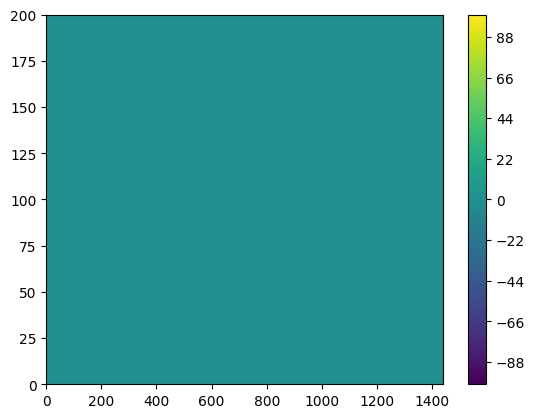

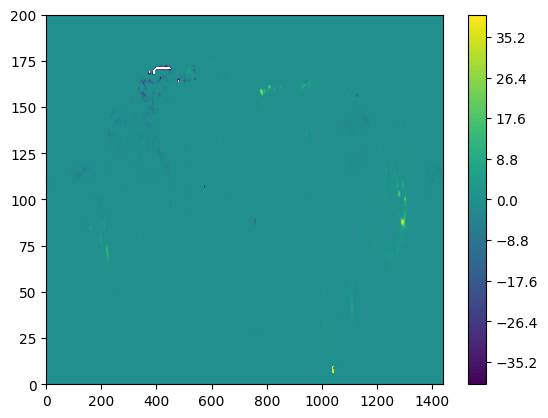

In [15]:
for X, y, _ in dsTest:
    y_pred = model.predict(X)
    plt.contourf(y_pred[0, :, :], np.linspace(-50, 50, 101))
    plt.colorbar()
    plt.show()
    plt.contourf(y[0, :, :], np.linspace(-50, 50, 101))
    plt.colorbar()
    plt.show()
    break

## Удачные эксперименты

"batch_size": 12

"variables": ['aice']
model = create_nn('aice', UNetModel, 
    {'input_channels': len(dsTrain.variables), 'base_channels': 4 },
    test=dsTest, lr=0.0005, epochs=200, verbose=True, seed=42)
0.8974 при том, что исходный прогноз 0.8749

"variables": ['aice', 'hice', 'sst', 't2min', 't2max', 'sin_period', 'cos_period']
model = create_nn('aice', UNetModel, 
    {'input_channels': len(dsTrain.variables), 'base_channels': 4 },
    test=dsTest, lr=0.001, epochs=300, verbose=True, seed=43)
На тесте 0.9004

model = create_nn('aice', UNetModel, 
    {'input_channels': len(dsTrain.variables), 'base_channels': 8 },
    test=dsTest, lr=0.001, epochs=200, verbose=True, seed=43)
На тесте 0.9044

model = create_nn('aice', UNetModel, 
    {'input_channels': len(dsTrain.variables), 'base_channels': 16 },
    test=dsTest, lr=0.0005, epochs=100, verbose=True, seed=43)
На тесте 0.9061

model = create_nn('aice', UNetModel, 
    {'input_channels': len(dsTrain.variables), 'base_channels': 32 },
    test=dsTest, lr=0.0005, epochs=150, verbose=True, seed=43)
На тесте 0.9101

model = create_nn('aice', RNNModel, 
    {'input_size': len(dsTrain.variables), 'hidden_size': 16, 'bidirectional': True},
    test=dsTest, lr=0.001, epochs=250, verbose=True, seed=42)
На тесте 0.9110

dsTrain, dsTest = make_ds('aice', args={"lead_times": [3],
                                        "normed": True,
                                        "cache_level": 2,
                                        "loader_type": "sequence", "loader_opts": { "len": 4 },
                                        "batch_size": 1_000_000,
                                        "variables": ['aice', 'hice', 'sst', 't2min', 't2max', 'sin_lon']})
model = create_nn('aice', RNNModel, 
    {'input_size': len(dsTrain.variables), 'hidden_size': 16, 'bidirectional': True},
    test=dsTest, lr=0.001, epochs=450, verbose=True, seed=42)
На тесте 0.9162

model = create_nn('aice', TCNModel, 
    {'input_size': len(dsTrain.variables), 'channels': [16, 16], 'kernel_size': 3 },
    test=dsTest, lr=0.001, epochs=350, verbose=True, seed=43)
На тесте 0.9175

model = create_nn('aice', LSTMModel,
    {'input_size': len(dsTrain.variables), 'hidden_size': 16, 'num_layers': 2, 'bidirectional': False},
    test=dsTest, lr=0.001, epochs=160, verbose=True, seed=42)
На тесте 0.9182

variables = ['swe']
"lead_times": [3], "periods": weeks, "batch_size": 8,
model = create_nn('swe', UNetModel, 
    {'input_channels': len(dsTrain.variables), 'base_channels': 16 },
    test=dsTest, lr=0.0001, epochs=120, verbose=True, seed=43)
На тесте 0.1790

model = create_nn('swe', RNNModel, 
    {'input_size': len(dsTrain.variables), 'hidden_size': 16, 'bidirectional': True},
    test=dsTest, lr=0.001, epochs=250, verbose=True, seed=42)
На тесте 0.1985

variables = ['swe', 'cld', 'olr', 'prec', 'ps', 'rq2', 't2', 't2max', 't2min', 't850', 'u850', 'uv10', 'ww', 'z',
             'sdor', 'cos_lat', 'sin_lon', 'cos_lon']
len=4, batch_size=100_000
model = create_nn('swe', RNNModel, 
    {'input_size': len(dsTrain.variables), 'hidden_size': 32, 'bidirectional': True}, # hidden_size=64 дает то же самое, но сходится быстрее
    test=dsTest, lr=0.0001, epochs=40, verbose=True, seed=42)
На тесте 0.2451

